In [50]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import json
import math

In [51]:
print("hello")


hello


In [52]:
import cv2 as cv
print(cv.__version__)


4.12.0


In [80]:
# Config

img_path = r"C:\Users\spaceoptics\Pictures\Camera Roll\6-08-L4.jpg"   # set your image path
dict_name = "DICT_4X4_100"                 # choose your 4x4 family: DICT_4X4_50/100/250/1000
allowed_ids = {0,1,2,3,4,5,6,7,8,9,10,11}   # <<< replace with YOUR printed IDs
use_CLAHE = True                           # True: local equalization; False: global hist eq
resize_factor = 1.0                         # e.g., 1.5 if markers are tiny/pixelated
print('A')

A


In [81]:
# Load + grayscale + enhance
img_bgr = cv.imread(img_path)
assert img_bgr is not None, f"Could not read image at {img_path}"
gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
print('B')

B


In [82]:
# Optional upsample for tiny markers
if resize_factor != 1.0:
    gray = cv.resize(gray, None, fx=resize_factor, fy=resize_factor, interpolation=cv.INTER_CUBIC)
    img_bgr = cv.resize(img_bgr, None, fx=resize_factor, fy=resize_factor, interpolation=cv.INTER_CUBIC)

# Contrast enhancement
if use_CLAHE:
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray_eq = clahe.apply(gray)
else:
    gray_eq = cv.equalizeHist(gray)

# ArUco detection (4x4 dict)
aruco_dict = cv.aruco.getPredefinedDictionary(getattr(cv.aruco, dict_name))

# Detector parameters (tuned for small/low-contrast markers)
try:
    params = cv.aruco.DetectorParameters()
except AttributeError:
    params = cv.aruco.DetectorParameters_create()

params.adaptiveThreshWinSizeMin = 3
params.adaptiveThreshWinSizeMax = 45
params.adaptiveThreshWinSizeStep = 3
params.adaptiveThreshConstant   = 7
params.minMarkerPerimeterRate   = 0.01
params.maxMarkerPerimeterRate   = 5.0
params.minCornerDistanceRate    = 0.01
params.cornerRefinementMethod   = cv.aruco.CORNER_REFINE_SUBPIX
print('C')

C


In [83]:
# Detect (handle both new/old OpenCV APIs)
try:
    detector = cv.aruco.ArucoDetector(aruco_dict, params)
    corners, ids, rejected = detector.detectMarkers(gray_eq)
except AttributeError:
    corners, ids, rejected = cv.aruco.detectMarkers(gray_eq, aruco_dict, parameters=params)

total_found = 0 if ids is None else len(ids)
print(f"[detect] Found {total_found} candidate markers using {dict_name}")

# Filter to allowed_ids
filtered_corners, filtered_ids = [], []
rejected_by_id = []  # for visualization/debug
print('D')

[detect] Found 12 candidate markers using DICT_4X4_100
D


In [84]:
if ids is not None:
    for c, i in zip(corners, ids.flatten()):
        if int(i) in allowed_ids:
            filtered_corners.append(c)
            filtered_ids.append([int(i)])   # keep as nested list for OpenCV
        else:
            rejected_by_id.append((c, int(i)))

if len(filtered_ids) == 0:
    print("[filter] No allowed markers detected!")
else:
    print(f"[filter] Kept {len(filtered_ids)} markers from allowed IDs: {sorted(allowed_ids)}")

# Convert to numpy for downstream OpenCV calls
ids_kept = np.array(filtered_ids, dtype=np.int32) if filtered_ids else None
corners_kept = filtered_corners
print('E')

[filter] Kept 12 markers from allowed IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
E


In [85]:
# Build a nice visualization
#   - green boxes = kept (allowed)
#   - red boxes   = rejected-by-ID (optional)
vis = cv.cvtColor(gray_eq, cv.COLOR_GRAY2RGB)

# Draw kept markers in green
if ids_kept is not None and len(ids_kept) > 0:
    cv.aruco.drawDetectedMarkers(vis, corners_kept, ids_kept)
    for c, i in zip(corners_kept, ids_kept.flatten()):
        center = c.reshape(-1,2).mean(axis=0).astype(int)
        cv.putText(vis, f"{int(i)}", tuple(center), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2, cv.LINE_AA)

# Optionally draw rejected-by-ID in red (helps you see the false positive)
for c, i in rejected_by_id:
    pts = c.reshape(4,2).astype(int)
    cv.polylines(vis, [pts], True, (255,0,0), 2, cv.LINE_AA)
    center = pts.mean(axis=0).astype(int)
    cv.putText(vis, f"rej {int(i)}", tuple(center), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2, cv.LINE_AA)
print('F')

F


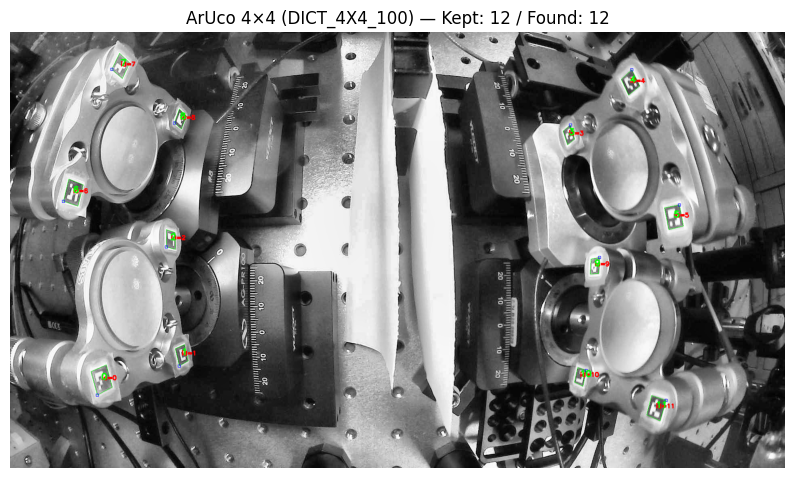

G


In [59]:
plt.figure(figsize=(10,10))
plt.imshow(vis)
plt.title(f"ArUco 4×4 ({dict_name}) — Kept: {0 if ids_kept is None else len(ids_kept)} / Found: {total_found}")
plt.axis('off')
plt.show()
print('G')

In [71]:
# Collect outputs for downstream use
detected = []
if ids_kept is not None:
    for c, i in zip(corners_kept, ids_kept.flatten()):
        pts = c.reshape(4,2).astype(float)    # TL, TR, BR, BL
        center = pts.mean(axis=0)
        # If you upsampled (resize_factor != 1), pts/center are already in the resized pixel space.
        # If you want original-image coordinates instead, divide by resize_factor here.
        detected.append({"id": int(i), "corners": pts, "center": center})
print('H')

print(f"[out] Ready: detected list with {len(detected)} kept markers (ids, corners, centers).")
# Example peek:
for d in detected[:5]:
    print(f"  id={d['id']}, center={d['center']}, TL={d['corners'][0]}")

H
[out] Ready: detected list with 12 kept markers (ids, corners, centers).
  id=0, center=[311.10617065 884.59898376], TL=[301.77203369 924.41589355]
  id=10, center=[1458.06936646  867.87501526], TL=[1472.  854.]
  id=6, center=[164.56581879 403.20563507], TL=[139. 423.]
  id=9, center=[1498.17868042  595.68540955], TL=[1509.  576.]
  id=7, center=[280.99903107  86.71347237], TL=[258.09295654  92.53130341]


A
B
C
[detect] Found 0 candidate markers using DICT_4X4_100
D
[filter] No allowed markers detected!
E
F


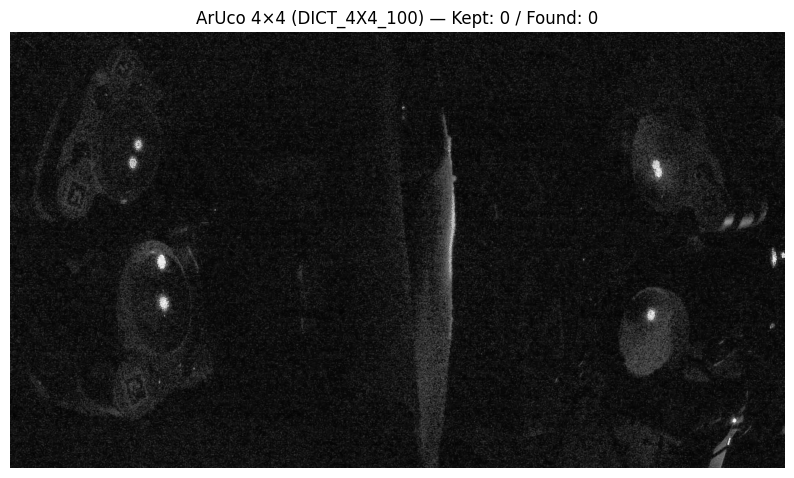

G
H
[out] Ready: detected list with 0 kept markers (ids, corners, centers).


In [73]:
# Config

img_path = r"C:\Users\spaceoptics\Pictures\Camera Roll\WIN_20260213_12_47_41_Pro.jpg"   # set your image path
dict_name = "DICT_4X4_100"                 # choose your 4x4 family: DICT_4X4_50/100/250/1000
allowed_ids = {0,1,2,3,4,5,6,7,8,9,10,11}   # <<< replace with YOUR printed IDs
use_CLAHE = True                           # True: local equalization; False: global hist eq
resize_factor = 1.0                         # e.g., 1.5 if markers are tiny/pixelated
print('A')

# Load + grayscale + enhance
img_bgr = cv.imread(img_path)
assert img_bgr is not None, f"Could not read image at {img_path}"
gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
print('B')

# Optional upsample for tiny markers
if resize_factor != 1.0:
    gray = cv.resize(gray, None, fx=resize_factor, fy=resize_factor, interpolation=cv.INTER_CUBIC)
    img_bgr = cv.resize(img_bgr, None, fx=resize_factor, fy=resize_factor, interpolation=cv.INTER_CUBIC)

# Contrast enhancement
if use_CLAHE:
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray_eq = clahe.apply(gray)
else:
    gray_eq = cv.equalizeHist(gray)

# ArUco detection (4x4 dict)
aruco_dict = cv.aruco.getPredefinedDictionary(getattr(cv.aruco, dict_name))

# Detector parameters (tuned for small/low-contrast markers)
try:
    params = cv.aruco.DetectorParameters()
except AttributeError:
    params = cv.aruco.DetectorParameters_create()

params.adaptiveThreshWinSizeMin = 3
params.adaptiveThreshWinSizeMax = 45
params.adaptiveThreshWinSizeStep = 3
params.adaptiveThreshConstant   = 7
params.minMarkerPerimeterRate   = 0.01
params.maxMarkerPerimeterRate   = 5.0
params.minCornerDistanceRate    = 0.01
params.cornerRefinementMethod   = cv.aruco.CORNER_REFINE_SUBPIX
print('C')

# Detect (handle both new/old OpenCV APIs)
try:
    detector = cv.aruco.ArucoDetector(aruco_dict, params)
    corners, ids, rejected = detector.detectMarkers(gray_eq)
except AttributeError:
    corners, ids, rejected = cv.aruco.detectMarkers(gray_eq, aruco_dict, parameters=params)

total_found = 0 if ids is None else len(ids)
print(f"[detect] Found {total_found} candidate markers using {dict_name}")

# Filter to allowed_ids
filtered_corners, filtered_ids = [], []
rejected_by_id = []  # for visualization/debug
print('D')

if ids is not None:
    for c, i in zip(corners, ids.flatten()):
        if int(i) in allowed_ids:
            filtered_corners.append(c)
            filtered_ids.append([int(i)])   # keep as nested list for OpenCV
        else:
            rejected_by_id.append((c, int(i)))

if len(filtered_ids) == 0:
    print("[filter] No allowed markers detected!")
else:
    print(f"[filter] Kept {len(filtered_ids)} markers from allowed IDs: {sorted(allowed_ids)}")

# Convert to numpy for downstream OpenCV calls
ids_kept = np.array(filtered_ids, dtype=np.int32) if filtered_ids else None
corners_kept = filtered_corners
print('E')

# Build a nice visualization
#   - green boxes = kept (allowed)
#   - red boxes   = rejected-by-ID (optional)
vis = cv.cvtColor(gray_eq, cv.COLOR_GRAY2RGB)

# Draw kept markers in green
if ids_kept is not None and len(ids_kept) > 0:
    cv.aruco.drawDetectedMarkers(vis, corners_kept, ids_kept)
    for c, i in zip(corners_kept, ids_kept.flatten()):
        center = c.reshape(-1,2).mean(axis=0).astype(int)
        cv.putText(vis, f"{int(i)}", tuple(center), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2, cv.LINE_AA)

# Optionally draw rejected-by-ID in red (helps you see the false positive)
for c, i in rejected_by_id:
    pts = c.reshape(4,2).astype(int)
    cv.polylines(vis, [pts], True, (255,0,0), 2, cv.LINE_AA)
    center = pts.mean(axis=0).astype(int)
    cv.putText(vis, f"rej {int(i)}", tuple(center), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2, cv.LINE_AA)
print('F')

plt.figure(figsize=(10,10))
plt.imshow(vis)
plt.title(f"ArUco 4×4 ({dict_name}) — Kept: {0 if ids_kept is None else len(ids_kept)} / Found: {total_found}")
plt.axis('off')
plt.show()
print('G')

# Collect outputs for downstream use
detected = []
if ids_kept is not None:
    for c, i in zip(corners_kept, ids_kept.flatten()):
        pts = c.reshape(4,2).astype(float)    # TL, TR, BR, BL
        center = pts.mean(axis=0)
        # If you upsampled (resize_factor != 1), pts/center are already in the resized pixel space.
        # If you want original-image coordinates instead, divide by resize_factor here.
        detected.append({"id": int(i), "corners": pts, "center": center})
print('H')

print(f"[out] Ready: detected list with {len(detected)} kept markers (ids, corners, centers).")
# Example peek:
for d in detected[:5]:
    print(f"  id={d['id']}, center={d['center']}, TL={d['corners'][0]}")